In [1]:
import pandas as pd
import numpy as np
import requests

In [2]:
# 1. Load and Clean the Corporate Data
df = pd.read_csv('Corporate_Energy_Consumption_20260506.csv', low_memory=False)

In [3]:
# Clean target variable and create proper datetime
df['Total Consumption'] = df['Total Consumption'].astype(str).str.replace(',', '').astype(float)
month_map = {'Jan':'01', 'Feb':'02', 'Mar':'03', 'Apr':'04', 'May':'05', 'Jun':'06', 
             'Jul':'07', 'Aug':'08', 'Sep':'09', 'Oct':'10', 'Nov':'11', 'Dec':'12'}
df['Month_Num'] = df['Month'].map(month_map)
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month_Num'] + '-01')

In [4]:
# Isolate Natural Gas for Methane/Heating analysis
df_gas = df[df['Energy Description'] == 'Natural Gas'].copy()

# Define the "Spike" (Target: > 90th percentile for that specific facility)
df_gas['Spike_Threshold'] = df_gas.groupby('FacilityName')['Total Consumption'].transform(lambda x: x.quantile(0.90))
df_gas['is_spike'] = (df_gas['Total Consumption'] > df_gas['Spike_Threshold']).astype(int)

In [5]:
# 2. Fetch Weather Data (Calgary Coordinates)
url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=51.0447&longitude=-114.0719&"
    "start_date=2014-01-01&end_date=2026-05-01&"
    "daily=temperature_2m_mean&timezone=America%2FEdmonton"
)
weather_data = requests.get(url).json()

# Process weather into monthly Heating Degree Days (HDD)
daily_weather = pd.DataFrame({
    'date': pd.to_datetime(weather_data['daily']['time']),
    'temp_mean_c': weather_data['daily']['temperature_2m_mean']
})
daily_weather['HDD'] = np.maximum(0, 18.0 - daily_weather['temp_mean_c'])
daily_weather['Year'] = daily_weather['date'].dt.year
daily_weather['Month'] = daily_weather['date'].dt.strftime('%b')

monthly_weather = daily_weather.groupby(['Year', 'Month']).agg(
    avg_monthly_temp_c=('temp_mean_c', 'mean'),
    total_monthly_hdd=('HDD', 'sum')
).reset_index()

In [6]:
# 3. Merge Datasets
df_final = pd.merge(df_gas, monthly_weather, on=['Year', 'Month'], how='left')

In [ ]:
#!pip install prophet
#!pip install plotly

In [7]:
from prophet import Prophet

# Prepare data for Prophet (requires 'ds' and 'y')
prophet_df = df_final[['Date', 'Total Consumption']].rename(columns={'Date': 'ds', 'Total Consumption': 'y'})
m = Prophet(yearly_seasonality=True)
m.fit(prophet_df)

# Generate baseline forecast feature ('yhat')
forecast = m.predict(prophet_df)
df_final['prophet_baseline'] = forecast['yhat'].values

18:41:15 - cmdstanpy - INFO - Chain [1] start processing
18:41:32 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [11]:
# Define which features are categorical and which are numeric
features = ['Business Unit Desc', 'avg_monthly_temp_c', 'total_monthly_hdd', 'prophet_baseline']
X = df_final[features]
y = df_final['is_spike']

# THIS IS THE MISSING DEFINITION:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Business Unit Desc'])
    ], 
    remainder='passthrough'
)

# Use the preprocessor to transform your data
X_encoded = preprocessor.fit_transform(X)

# Extract the feature names so XGBoost and SHAP know what columns are what
feature_names = preprocessor.get_feature_names_out()

In [12]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier
import numpy as np

# 1. Sort by Date (CRITICAL for Time-Series integrity)
df_final = df_final.sort_values('Date').reset_index(drop=True)

# Re-define features and target
features = ['Business Unit Desc', 'avg_monthly_temp_c', 'total_monthly_hdd', 'prophet_baseline']
X = df_final[features]
y = df_final['is_spike']

# Preprocess categorical data (using the preprocessor from Phase 2)
X_encoded = preprocessor.fit_transform(X)

# 2. Set up TimeSeriesSplit
# n_splits=5 creates 5 expanding time windows
tscv = TimeSeriesSplit(n_splits=5)

roc_auc_scores = []
pr_auc_scores = []

print("Starting Time-Series Cross-Validation...\n")

# 3. Iterate through the time splits
for fold, (train_index, test_index) in enumerate(tscv.split(X_encoded)):
    # Split data chronologically
    X_train, X_test = X_encoded[train_index], X_encoded[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Initialize XGBoost optimized for imbalanced classification
    xgb_model = XGBClassifier(
        objective='binary:logistic', 
        n_estimators=150, 
        learning_rate=0.05,
        eval_metric='aucpr', # Optimize for Precision-Recall
        early_stopping_rounds=10
    )
    
    # Fit the model, using the test set to stop early if it stops improving
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    
    # Predict probabilities for the test window
    y_probs = xgb_model.predict_proba(X_test)[:, 1]
    
    # Evaluate performance
    roc_auc = roc_auc_score(y_test, y_probs)
    pr_auc = average_precision_score(y_test, y_probs)
    
    roc_auc_scores.append(roc_auc)
    pr_auc_scores.append(pr_auc)
    
    print(f"Fold {fold + 1} | Training Set Size: {len(X_train)} | Test Set Size: {len(X_test)}")
    print(f"          ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")

# 4. Final Aggregated Metrics
print(f"\n--- Final Model Performance ---")
print(f"Average ROC-AUC: {np.mean(roc_auc_scores):.4f}")
print(f"Average PR-AUC:  {np.mean(pr_auc_scores):.4f}")

Starting Time-Series Cross-Validation...

Fold 1 | Training Set Size: 47512 | Test Set Size: 47510
          ROC-AUC: 0.9034 | PR-AUC: 0.3826
Fold 2 | Training Set Size: 95022 | Test Set Size: 47510
          ROC-AUC: 0.8953 | PR-AUC: 0.4707
Fold 3 | Training Set Size: 142532 | Test Set Size: 47510
          ROC-AUC: 0.8993 | PR-AUC: 0.4447
Fold 4 | Training Set Size: 190042 | Test Set Size: 47510
          ROC-AUC: 0.9257 | PR-AUC: 0.3973
Fold 5 | Training Set Size: 237552 | Test Set Size: 47510
          ROC-AUC: 0.8433 | PR-AUC: 0.3239

--- Final Model Performance ---
Average ROC-AUC: 0.8934
Average PR-AUC:  0.4038


In [ ]:
#pip install xgboost

In [13]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Features and Target
features = ['Business Unit Desc', 'avg_monthly_temp_c', 'total_monthly_hdd', 'prophet_baseline']
X = df_final[features]
y = df_final['is_spike']

# One-Hot Encode categorical business units (proxy for facility type/behavior)
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), ['Business Unit Desc'])],
    remainder='passthrough'
)
X_encoded = preprocessor.fit_transform(X)

# Time-series split (do not shuffle to prevent data leakage from the future)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, shuffle=False)

# Train XGBoost for probabilities
xgb_model = XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

# Predict Probability of a Spike
spike_probabilities = xgb_model.predict_proba(X_test)[:, 1]

In [14]:
def carbon_credit_calculator(spike_probabilities, average_spike_gj, prob_threshold=0.75, carbon_price_per_ton=65):
    """
    Estimates tax savings if a facility successfully intervenes on high-probability spikes.
    """
    emissions_factor_gj_to_co2e = 0.05 # Tons of CO2e per GJ of Natural Gas
    
    # Identify high-confidence actionable spikes
    actionable_spikes = (spike_probabilities > prob_threshold).sum()
    
    # Total GJ of natural gas prevented
    energy_saved_gj = actionable_spikes * average_spike_gj
    
    # Convert to CO2 equivalent
    co2e_saved_tons = energy_saved_gj * emissions_factor_gj_to_co2e
    
    # Calculate financial savings
    total_savings = co2e_saved_tons * carbon_price_per_ton
    
    return {
        "actionable_interventions": int(actionable_spikes),
        "natural_gas_saved_gj": energy_saved_gj,
        "co2e_mitigated_tons": round(co2e_saved_tons, 2),
        "estimated_tax_savings_usd": round(total_savings, 2)
    }

# Example: Assume a typical spike wastes 500 GJ of energy
results = carbon_credit_calculator(spike_probabilities, average_spike_gj=500)
print(f"Estimated Tax Savings: ${results['estimated_tax_savings_usd']:,.2f}")

Estimated Tax Savings: $0.00


SHAP values calculated successfully. Generating plots...


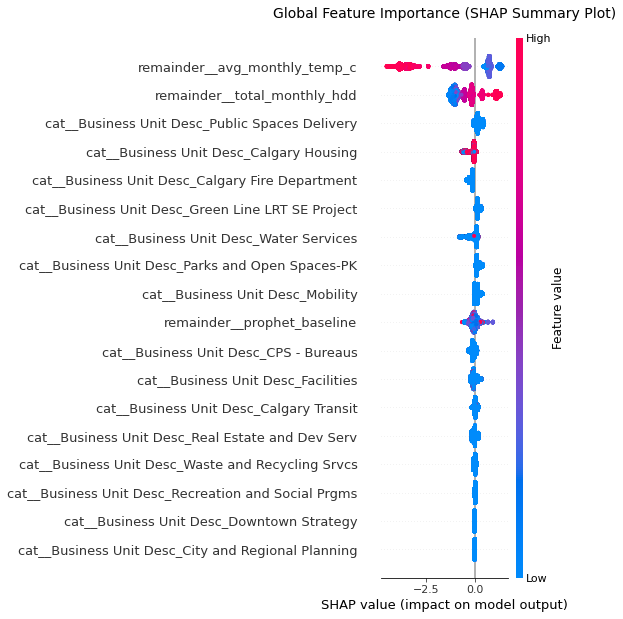

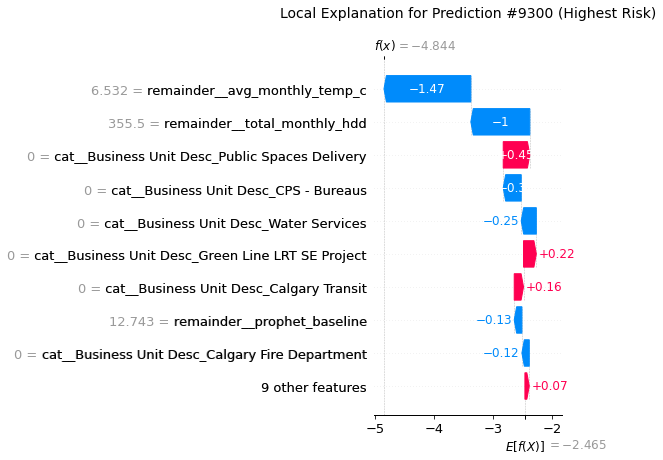

In [15]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract feature names from your pipeline
# This ensures our charts show readable names (like 'avg_monthly_temp_c') instead of raw array indices
feature_names = preprocessor.get_feature_names_out(features)

# Convert the final X_test array back to a DataFrame for readable SHAP plots
X_test_df = pd.DataFrame(X_test.toarray() if hasattr(X_test, 'toarray') else X_test, columns=feature_names)

# 2. Initialize the SHAP Tree Explainer
# We use the 'xgb_model' that was trained during the final fold of your TimeSeriesSplit
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the test set
shap_values = explainer(X_test_df)

print("SHAP values calculated successfully. Generating plots...")

# ==========================================
# Global Explainability: Summary Plot
# ==========================================
# This shows which features matter most across the ENTIRE dataset.
# Red means a high feature value, Blue means a low feature value.
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title("Global Feature Importance (SHAP Summary Plot)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# ==========================================
# Local Explainability: Waterfall Plot
# ==========================================
# This explains ONE specific prediction. Let's look at the worst-case scenario:
# We find the instance in the test set with the highest predicted probability of a spike.
highest_risk_index = y_probs.argmax()

plt.figure(figsize=(10, 6))
# Plot the waterfall for that specific high-risk facility/month
shap.plots.waterfall(shap_values[highest_risk_index], show=False)
plt.title(f"Local Explanation for Prediction #{highest_risk_index} (Highest Risk)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [16]:
# Create a summary table for the test results
test_results = df_final.iloc[y_test.index].copy()
test_results['spike_probability'] = spike_probabilities

# Set a threshold (e.g., only alert if probability is > 80%)
high_risk_alerts = test_results[test_results['spike_probability'] > 0.80]

In [17]:
# Configuration for the alert
AVG_SPIKE_GJ = 500
EMISSIONS_FACTOR = 0.05
CARBON_PRICE = 65

for index, row in high_risk_alerts.iterrows():
    # Calculate savings for this specific instance
    savings = 1 * AVG_SPIKE_GJ * EMISSIONS_FACTOR * CARBON_PRICE
    
    # Check if it's "cold" based on your temperature threshold (e.g., < 5°C)
    weather_condition = "cold" if row['avg_monthly_temp_c'] < 5 else "unusual"
    
    # The Resulting Sentence
    print(f"Hey, it's going to be {weather_condition} and {row['FacilityName']} "
          f"usually wastes gas in these conditions—fix it now and you'll "
          f"save ${savings:,.2f} in carbon taxes.")